
Dataset Shape:
(2823, 25)

First 5 Rows:
   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1  ADDRESSLINE2           CITY STATE  \
0        897 Long Airport Avenue           NaN            NYC    NY   
1   

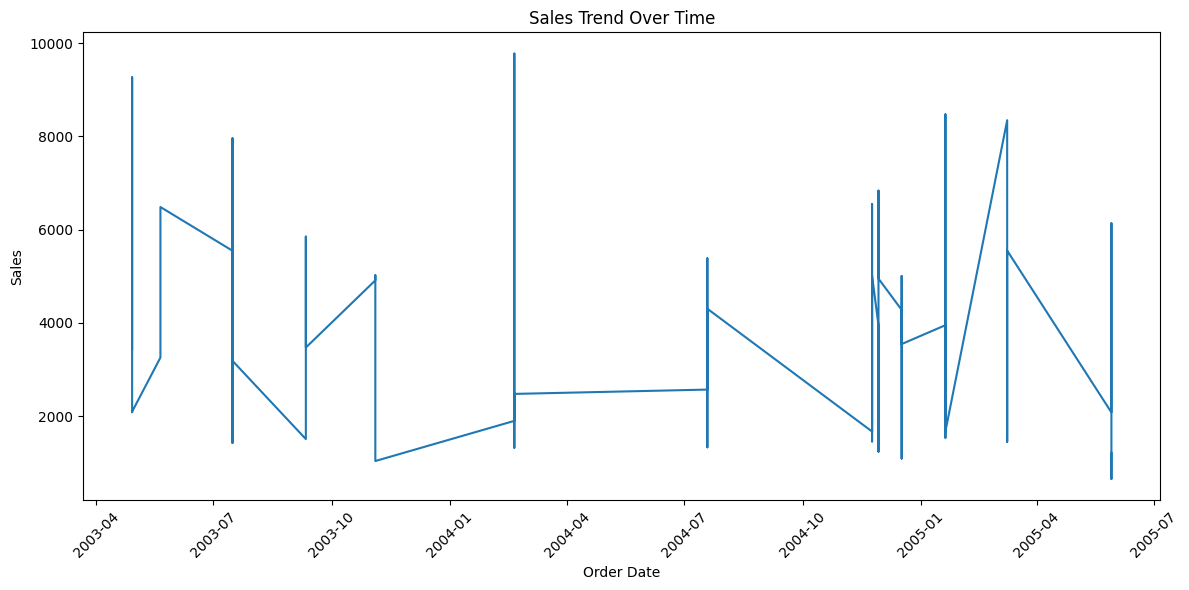

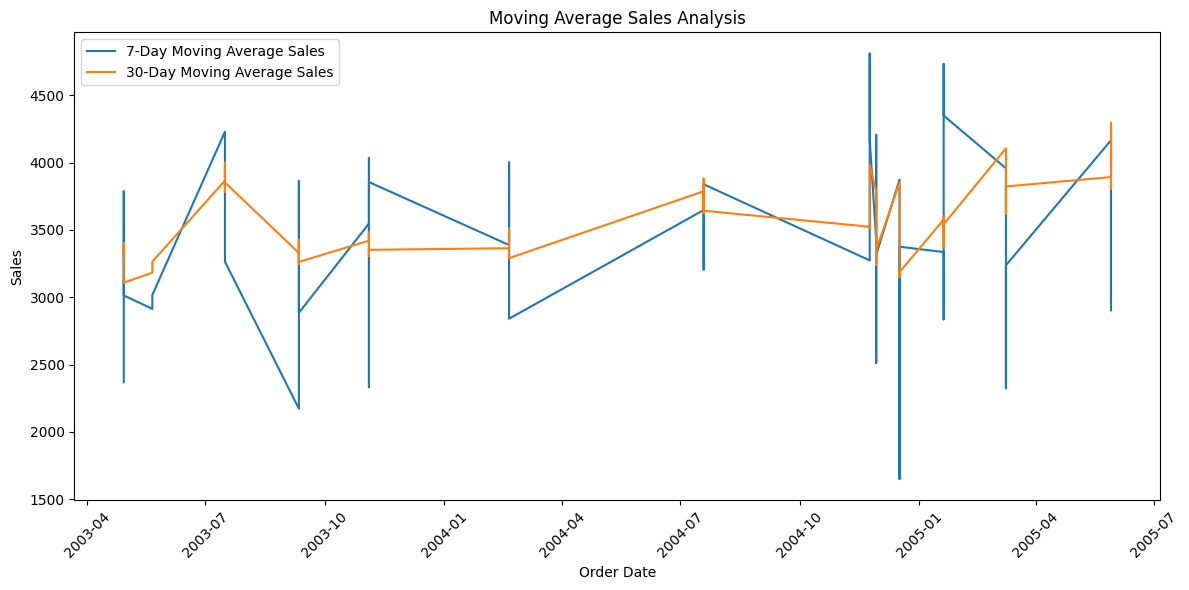

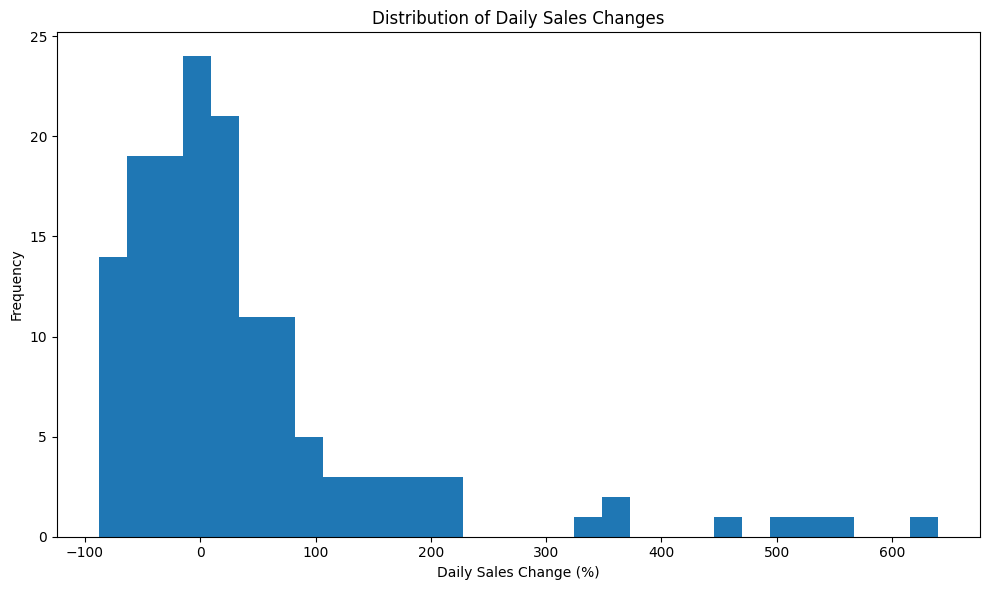

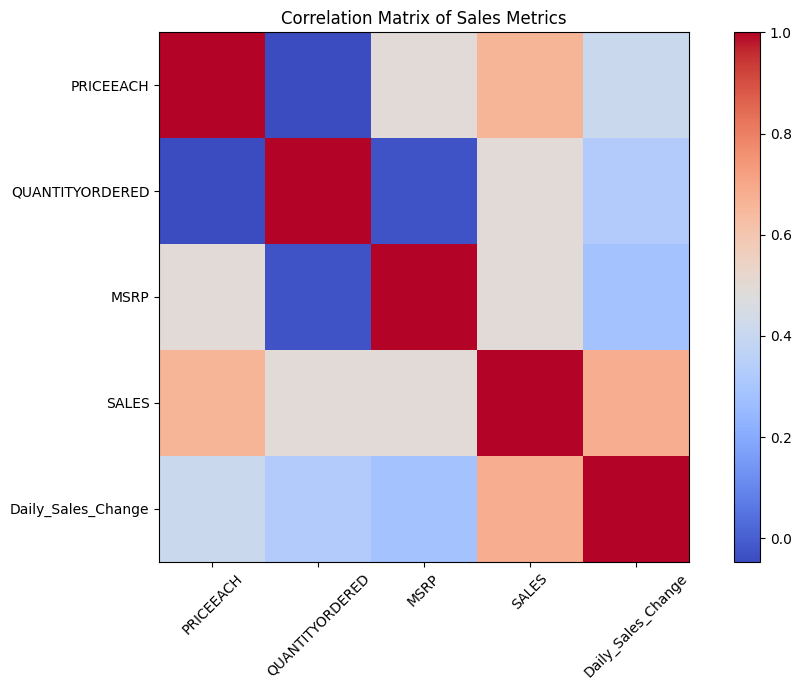


Model Performance
-------------------------
Mean Absolute Error: 628.0665362577209
Mean Squared Error: 929869.347037299
Root Mean Squared Error: 964.2973333144187
R2 Score: 0.7639058282720541

Prediction Results (first 20 rows):
     Actual    Predicted
0   1735.30  2245.502962
1   1035.58   127.843494
2   2233.69  1755.580413
3   3276.13  3924.423522
4   2189.60  2574.058571
5   2082.49  2015.451690
6   4048.00  4285.682288
7   5848.68  5296.094309
8   6548.30  7239.820851
9   2674.90  2657.735401
10  3598.22  4086.139493
11  5884.65  5009.077083
12   652.35  -666.627408
13  2567.84  2397.288133
14  2078.28  2536.066268
15  2475.27  2888.745871
16  1424.00  1124.436853
17  4775.08  4280.631903
18  8344.71  4393.873939
19  4392.12  4259.915132


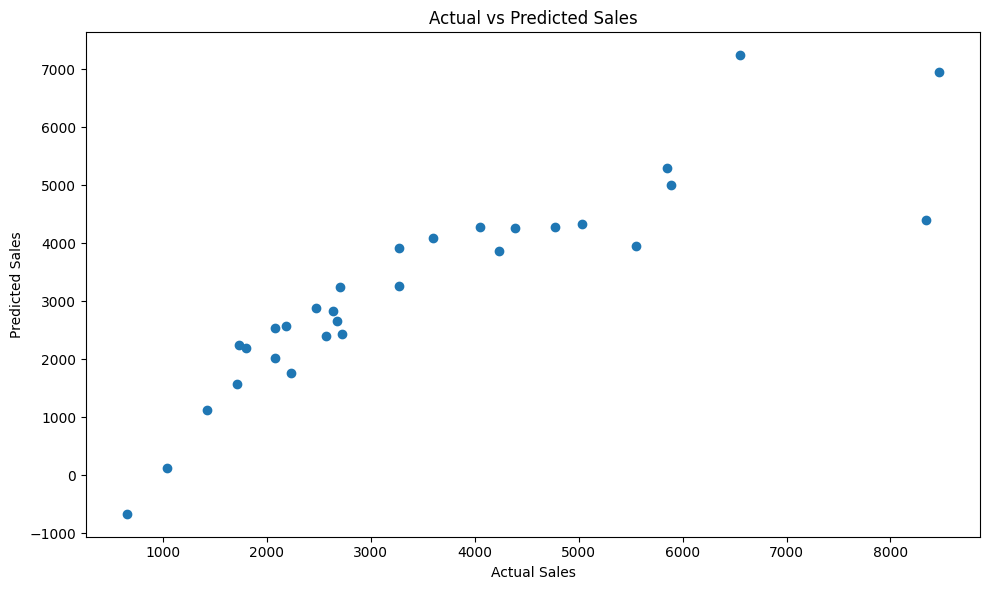

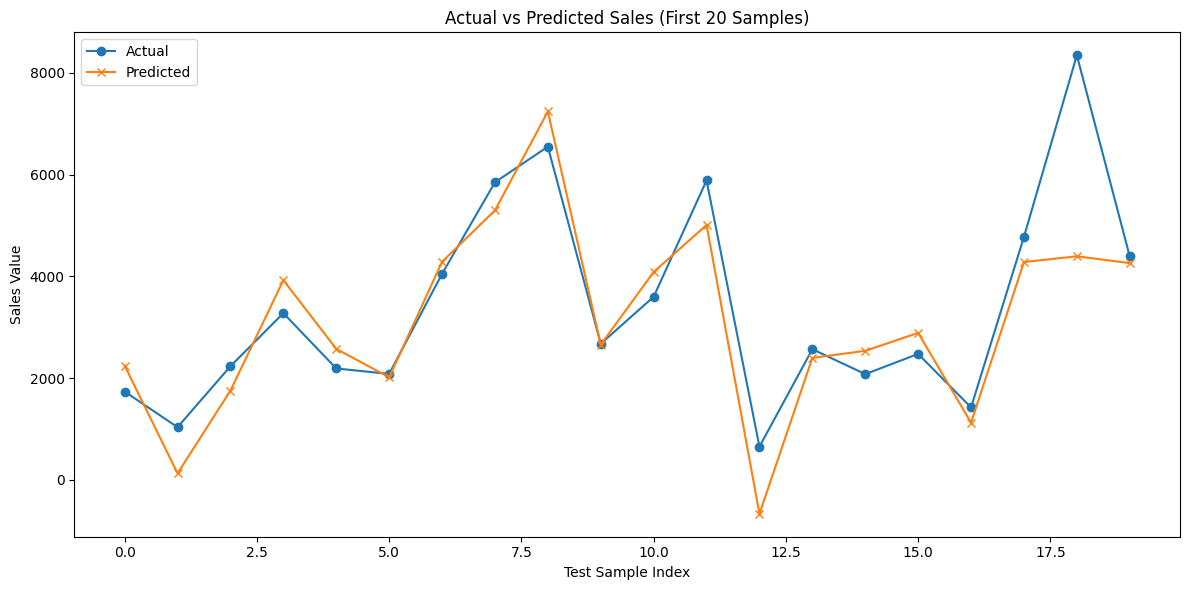


Model Coefficients:
PRICEEACH : 38.19463711102169
QUANTITYORDERED : 76.55061901993592
MSRP : 10.462408477428443
Moving_Average_7_Sales : 0.18166718213936406
Daily_Sales_Change : 3.408759078461202

Model Intercept:
-4232.213242584534

Files saved successfully:
/content/processed_sales_data.csv
/content/sales_predictions.csv


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("/content/sales_data_sample.csv", encoding='latin1')

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

df.columns = df.columns.str.strip()

# Identify relevant columns for sales data
date_col = next((col for col in df.columns if 'orderdate' in col.lower()), None)
target_col = next((col for col in df.columns if 'sales' in col.lower()), None)
feature_price_each_col = next((col for col in df.columns if 'priceeach' in col.lower()), None)
feature_quantity_ordered_col = next((col for col in df.columns if 'quantityordered' in col.lower()), None)
feature_msrp_col = next((col for col in df.columns if 'msrp' in col.lower()), None)

required_columns_for_analysis = [
    date_col,
    target_col,
    feature_price_each_col,
    feature_quantity_ordered_col,
    feature_msrp_col
]

if any(col is None for col in required_columns_for_analysis):
    print("\nAvailable columns:")
    print(df.columns.tolist())
    missing_cols = [col for col in ['ORDERDATE', 'SALES', 'PRICEEACH', 'QUANTITYORDERED', 'MSRP'] if col not in [c.upper() for c in df.columns]]
    raise ValueError(f"Required columns {missing_cols} were not found in the dataset.")

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

numeric_features_to_convert = [
    feature_price_each_col,
    feature_quantity_ordered_col,
    feature_msrp_col,
    target_col
]

for column in numeric_features_to_convert:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Drop rows with NaN in the core columns identified for analysis
df = df.dropna(subset=[date_col, target_col, feature_price_each_col, feature_quantity_ordered_col, feature_msrp_col])
df = df.drop_duplicates()
df = df.sort_values(date_col)
df = df.reset_index(drop=True)

# Feature Engineering for sales data
df["Daily_Sales_Change"] = df[target_col].pct_change() * 100
df["Sales_Price_Difference"] = df[target_col] - df[feature_price_each_col]
df["Moving_Average_7_Sales"] = df[target_col].rolling(7).mean()
df["Moving_Average_30_Sales"] = df[target_col].rolling(30).mean()

df = df.dropna().reset_index(drop=True)

print("\nCleaned Dataset Shape:")
print(df.shape)

print("\nMissing Values (after cleaning):")
print(df.isnull().sum())

print("\nCleaned Dataset Head:")
print(df.head())

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(df[date_col], df[target_col])
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.title("Sales Trend Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df[date_col], df["Moving_Average_7_Sales"], label="7-Day Moving Average Sales")
plt.plot(df[date_col], df["Moving_Average_30_Sales"], label="30-Day Moving Average Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.title("Moving Average Sales Analysis")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df["Daily_Sales_Change"], bins=30)
plt.xlabel("Daily Sales Change (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Sales Changes")
plt.tight_layout()
plt.show()

correlation_columns = [
    feature_price_each_col,
    feature_quantity_ordered_col,
    feature_msrp_col,
    target_col,
    "Daily_Sales_Change"
]

correlation = df[correlation_columns].corr()

plt.figure(figsize=(10, 7))
plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)
plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)
plt.title("Correlation Matrix of Sales Metrics")
plt.tight_layout()
plt.show()

# Linear Regression Model
features = [
    feature_price_each_col,
    feature_quantity_ordered_col,
    feature_msrp_col,
    "Moving_Average_7_Sales",
    "Daily_Sales_Change"
]

target = target_col

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("-------------------------")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nPrediction Results (first 20 rows):")
print(results.head(20))

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.tight_layout()
plt.show()

comparison = results.head(20)

plt.figure(figsize=(12, 6))
plt.plot(
    range(len(comparison)),
    comparison["Actual"],
    marker="o",
    label="Actual"
)
plt.plot(
    range(len(comparison)),
    comparison["Predicted"],
    marker="x",
    label="Predicted"
)
plt.xlabel("Test Sample Index")
plt.ylabel("Sales Value")
plt.title("Actual vs Predicted Sales (First 20 Samples)")
plt.legend()
plt.tight_layout()
plt.show()

print("\nModel Coefficients:")
for feature, coefficient in zip(features, model.coef_):
    print(feature, ":", coefficient)

print("\nModel Intercept:")
print(model.intercept_)

df.to_csv("/content/processed_sales_data.csv", index=False)
results.to_csv("/content/sales_predictions.csv", index=False)

print("\nFiles saved successfully:")
print("/content/processed_sales_data.csv")
print("/content/sales_predictions.csv")